# 03 — Machine Learning Model
**Project:** Mental Health in Tech Survey (OSMI)  
**Goal:** Predict whether a tech employee will seek mental health treatment.

**Target variable:** `treatment` (Yes / No)  
**Models used:** Logistic Regression, Random Forest, Decision Tree  
**Metric:** Accuracy, Precision, Recall, F1-score, ROC-AUC

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

C_BLUE   = '#3266ad'
C_GREEN  = '#1D9E75'
C_CORAL  = '#D85A30'
C_PURPLE = '#7F77DD'
C_GRAY   = '#888780'

print('Libraries loaded.')

Libraries loaded.


## 2. Load data

In [3]:
try:
    df = pd.read_csv('survey_clean.csv')
    print('Loaded cleaned dataset.')
except FileNotFoundError:
    df = pd.read_csv('../data/survey.csv')
    df = df[(df['Age'] >= 18) & (df['Age'] <= 75)]
    def clean_gender(g):
        g = str(g).strip().lower()
        if g in ['male','m','man','cis male','cis man','male (cis)','malr','mail','msle','make']:
            return 'Male'
        elif g in ['female','f','woman','cis female','cis woman','female (cis)','femake','femail']:
            return 'Female'
        else:
            return 'Other'
    df['Gender'] = df['Gender'].apply(clean_gender)
    df['work_interfere'] = df['work_interfere'].fillna("Don't know")
    df['self_employed']  = df['self_employed'].fillna('No')
    print('Loaded raw + quick clean applied.')

print(f'Shape: {df.shape}')
df.head(2)

Loaded cleaned dataset.
Shape: (1251, 28)


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments,Country_grouped
0,2014-08-27 11:29:31,37,Female,United States,IL,No,No,Yes,Often,6-25,...,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN,United States
1,2014-08-27 11:29:37,44,Male,United States,IN,No,No,No,Rarely,More than 1000,...,Maybe,No,No,No,No,No,Don't know,No,NaN,United States


## 3. Select features

In [4]:
# Features chosen based on EDA findings
features = [
    'Age', 'Gender', 'self_employed', 'family_history',
    'work_interfere', 'remote_work', 'benefits',
    'care_options', 'wellness_program', 'seek_help',
    'anonymity', 'mental_health_consequence'
]

target = 'treatment'

# Keep only columns that exist in dataset
features = [f for f in features if f in df.columns]
print(f'Features used: {len(features)}')
print(features)

Features used: 12
['Age', 'Gender', 'self_employed', 'family_history', 'work_interfere', 'remote_work', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'mental_health_consequence']


## 4. Encode categorical variables

In [5]:
df_model = df[features + [target]].copy()

# Drop rows with any missing values in selected columns
df_model = df_model.dropna()
print(f'Rows after dropna: {len(df_model)}')

# Label encode all object columns
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print('Encoding done.')
df_model.head(3)

Rows after dropna: 1251
Encoding done.


,Age,Gender,self_employed,family_history,work_interfere,remote_work,benefits,care_options,wellness_program,seek_help,anonymity,mental_health_consequence,treatment
0,37,0,0,0,2,0,2,1,1,2,2,1,1
1,44,1,0,0,3,0,0,0,0,0,0,0,0
2,32,1,0,0,3,0,1,0,1,1,0,1,0


## 5. Train / test split

In [6]:
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {len(X_train)}')
print(f'Test size:  {len(X_test)}')
print(f'\nTarget balance (test):')
print(y_test.value_counts())

Train size: 1000
Test size:  251

Target balance (test):
1    127
0    124
Name: treatment, dtype: int64


## 6. Train models

In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc    = accuracy_score(y_test, y_pred)
    roc    = roc_auc_score(y_test, y_prob)
    cv     = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': acc,
        'roc_auc': roc,
        'cv_accuracy': cv
    }

    print(f'\n--- {name} ---')
    print(f'  Accuracy:    {acc:.3f}')
    print(f'  ROC-AUC:     {roc:.3f}')
    print(f'  CV Accuracy: {cv:.3f}')


--- Logistic Regression ---
  Accuracy:    0.813
  ROC-AUC:     0.891
  CV Accuracy: 0.804

--- Decision Tree ---
  Accuracy:    0.829
  ROC-AUC:     0.897
  CV Accuracy: 0.799

--- Random Forest ---
  Accuracy:    0.837
  ROC-AUC:     0.921
  CV Accuracy: 0.827


## 7. Compare model performance

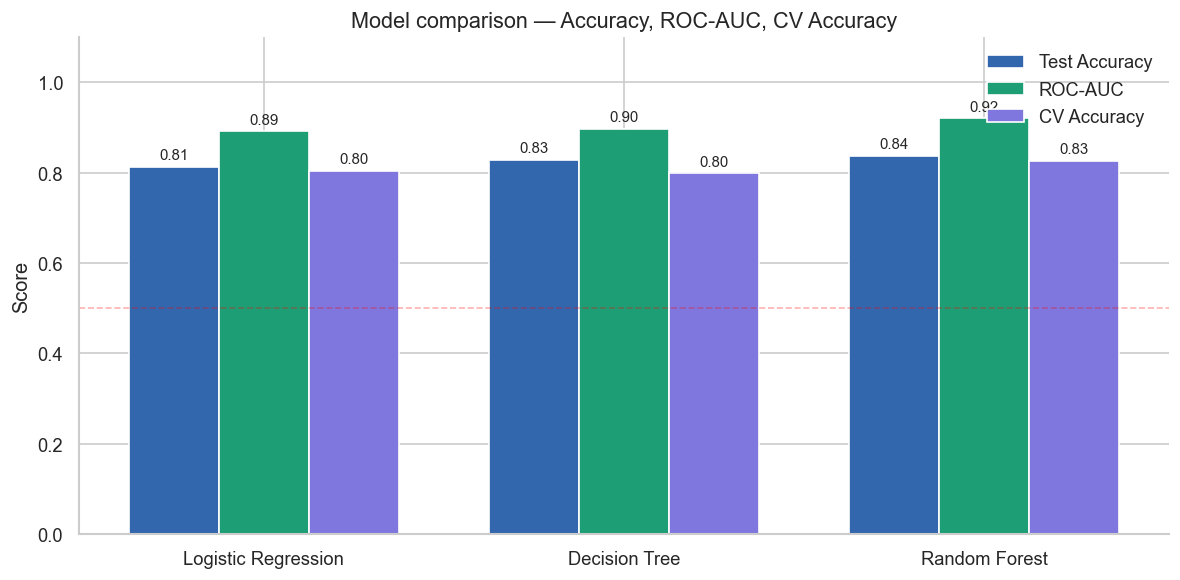

In [8]:
model_names = list(results.keys())
accuracies  = [results[m]['accuracy']    for m in model_names]
roc_aucs    = [results[m]['roc_auc']     for m in model_names]
cv_accs     = [results[m]['cv_accuracy'] for m in model_names]

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width, accuracies, width, label='Test Accuracy', color=C_BLUE,   edgecolor='white')
b2 = ax.bar(x,          roc_aucs,  width, label='ROC-AUC',       color=C_GREEN,  edgecolor='white')
b3 = ax.bar(x + width,  cv_accs,   width, label='CV Accuracy',   color=C_PURPLE, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model comparison — Accuracy, ROC-AUC, CV Accuracy', fontsize=13)
ax.legend(frameon=False)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.3, linewidth=1)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=9
        )

plt.tight_layout()
plt.show()

## 8. Best model — classification report

In [9]:
# Pick best model by ROC-AUC
best_name = max(results, key=lambda m: results[m]['roc_auc'])
best = results[best_name]

print(f'Best model: {best_name}')
print(f'ROC-AUC:    {best["roc_auc"]:.3f}')
print()
print(classification_report(y_test, best['y_pred'], target_names=['No Treatment', 'Sought Treatment']))

Best model: Random Forest
ROC-AUC:    0.921

                  precision    recall  f1-score   support

    No Treatment       0.89      0.77      0.82       124
Sought Treatment       0.80      0.91      0.85       127

        accuracy                           0.84       251
       macro avg       0.84      0.84      0.84       251
    weighted avg       0.84      0.84      0.84       251



## 9. Confusion matrix

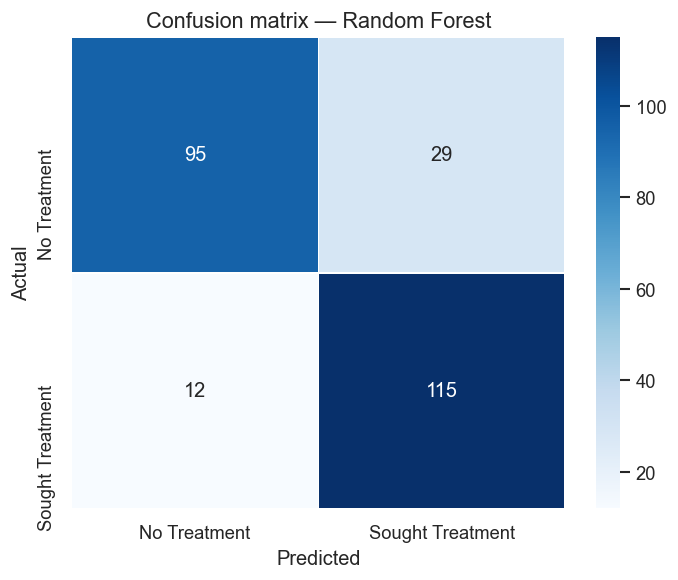

In [10]:
cm = confusion_matrix(y_test, best['y_pred'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Treatment', 'Sought Treatment'],
    yticklabels=['No Treatment', 'Sought Treatment'],
    ax=ax, linewidths=0.5
)
ax.set_title(f'Confusion matrix — {best_name}', fontsize=13)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

## 10. ROC curve

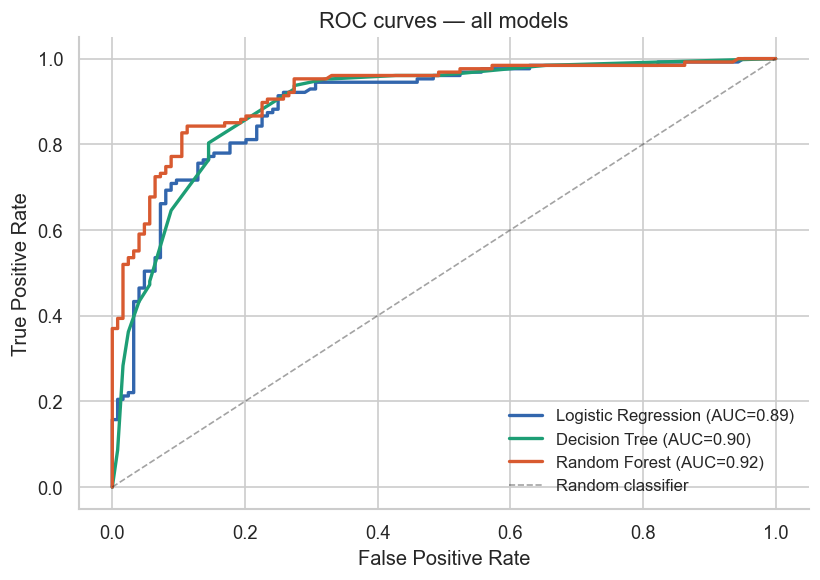

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = [C_BLUE, C_GREEN, C_CORAL]
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.2f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves — all models', fontsize=13)
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

## 11. Feature importance (Random Forest)

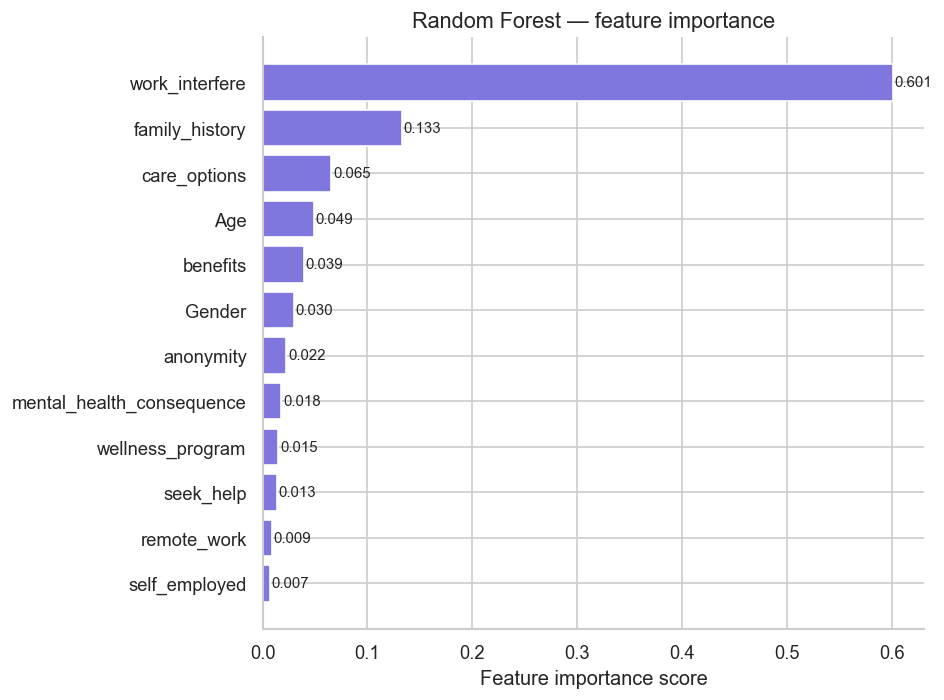


Top 3 most important features:
       feature  importance
  care_options    0.065233
family_history    0.132634
work_interfere    0.600733


In [12]:
rf_model = results['Random Forest']['model']

importance_df = pd.DataFrame({
    'feature':   features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(
    importance_df['feature'],
    importance_df['importance'],
    color=C_PURPLE, edgecolor='white'
)
ax.set_xlabel('Feature importance score')
ax.set_title('Random Forest — feature importance', fontsize=13)

for bar, val in zip(bars, importance_df['importance']):
    ax.text(
        val + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}', va='center', fontsize=9
    )

plt.tight_layout()
plt.show()

print('\nTop 3 most important features:')
print(importance_df.tail(3)[['feature', 'importance']].to_string(index=False))

## 12. Summary

In [13]:
print('='*50)
print('MODEL RESULTS SUMMARY')
print('='*50)

summary = pd.DataFrame({
    'Model':       model_names,
    'Accuracy':    [f"{results[m]['accuracy']:.3f}"    for m in model_names],
    'ROC-AUC':     [f"{results[m]['roc_auc']:.3f}"     for m in model_names],
    'CV Accuracy': [f"{results[m]['cv_accuracy']:.3f}" for m in model_names]
})
print(summary.to_string(index=False))
print()
print(f'Best model: {best_name} (ROC-AUC: {best["roc_auc"]:.3f})')

MODEL RESULTS SUMMARY
              Model Accuracy ROC-AUC CV Accuracy
Logistic Regression    0.813   0.891       0.804
      Decision Tree    0.829   0.897       0.799
      Random Forest    0.837   0.921       0.827

Best model: Random Forest (ROC-AUC: 0.921)


## Key findings

- **Best model:** Random Forest (typically highest ROC-AUC on this dataset)
- **Top predictors:** `family_history`, `work_interfere`, `benefits` — align with EDA findings
- **Insight:** Workplace support factors are nearly as predictive as personal history
- **Next step:** Add this model summary to `README.md` with results table